In [52]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


DATA_PATH = Path("../data/processed/transactions_clean.csv")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["invoice_date"],
)

df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,is_cancellation,revenue,year,month,year_month,day_of_week,hour,has_customer_id
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30,2010,12,2010-12,Wednesday,8,True
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010,12,2010-12,Wednesday,8,True
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00,2010,12,2010-12,Wednesday,8,True
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010,12,2010-12,Wednesday,8,True
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010,12,2010-12,Wednesday,8,True


In [53]:
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")

df.info()

Rows: 534,129
Columns: 16
<class 'pandas.DataFrame'>
RangeIndex: 534129 entries, 0 to 534128
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   invoice_no       534129 non-null  str           
 1   stock_code       534129 non-null  str           
 2   description      534129 non-null  str           
 3   quantity         534129 non-null  int64         
 4   invoice_date     534129 non-null  datetime64[us]
 5   unit_price       534129 non-null  float64       
 6   customer_id      401564 non-null  float64       
 7   country          534129 non-null  str           
 8   is_cancellation  534129 non-null  bool          
 9   revenue          534129 non-null  float64       
 10  year             534129 non-null  int64         
 11  month            534129 non-null  int64         
 12  year_month       534129 non-null  str           
 13  day_of_week      534129 non-null  str           
 14  hour 

Creating Sales data frame

In [54]:
sales_df = df[
    (df["quantity"] > 0)
    & (~df["is_cancellation"])
    & (df["unit_price"] > 0)
].copy()

Cancellations are retained in the complete cleaned dataset because they represent meaningful business activity and may be analyzed separately. They are excluded from sales_df because this DataFrame is intended to measure successful sales performance, such as revenue, product demand and customer purchasing behavior.

In [55]:
print(f"All cleaned rows: {len(df):,}")
print(f"Successful sales rows: {len(sales_df):,}")

sales_df[
    ["quantity", "unit_price", "revenue", "is_cancellation"]
].describe(include="all")

All cleaned rows: 534,129
Successful sales rows: 524,878


,quantity,unit_price,revenue,is_cancellation
count,524878.000000,524878.000000,524878.000000,524878
unique,NaN,NaN,NaN,1
top,NaN,NaN,NaN,False
freq,NaN,NaN,NaN,524878
mean,10.616600,3.922573,20.275399,NaN
std,156.280031,36.093028,271.693566,NaN
min,1.000000,0.001000,0.001000,NaN
25%,1.000000,1.250000,3.900000,NaN
50%,4.000000,2.080000,9.920000,NaN
75%,11.000000,4.130000,17.700000,NaN


In [56]:
sales_df["is_cancellation"].value_counts(dropna=False)

is_cancellation
False    524878
Name: count, dtype: int64

In [57]:
sales_df["quantity"].min()

np.int64(1)

In [58]:
sales_df["unit_price"].min()

np.float64(0.001)

Mean, median and revenue distribution

In [59]:
revenue = sales_df["revenue"]
revenue_summary = {
    "mean": revenue.mean(),
    "median": revenue.median(),
    "minimum": revenue.min(),
    "maximum": revenue.max(),
    "standard_deviation": revenue.std(),
    "q1": revenue.quantile(0.25),

    "q3": revenue.quantile(0.75),
}

In [60]:
pd.Series(revenue_summary)

mean                      20.275399
median                     9.920000
minimum                    0.001000
maximum               168469.600000
standard_deviation       271.693566
q1                         3.900000
q3                        17.700000
dtype: float64

### Revenue distribution interpretation

1. The mean revenue is higher than the median revenue.

2. This suggests that the distribution is right-skewed. Most transaction
   lines have relatively low revenue, while a small number have very high
   revenue.

3. The median is a better representation of a typical transaction line
   because it is less affected by extreme values.

4. Extremely high transaction-line revenue may result from unusually large
   quantities, expensive products, wholesale purchases, or possible data
   anomalies. These rows should be investigated before deciding whether they
   are errors.

In [61]:
revenue_p99 = sales_df["revenue"].quantile(0.99)

In [62]:
revenue_for_plot = sales_df[
    sales_df["revenue"] <= revenue_p99
]

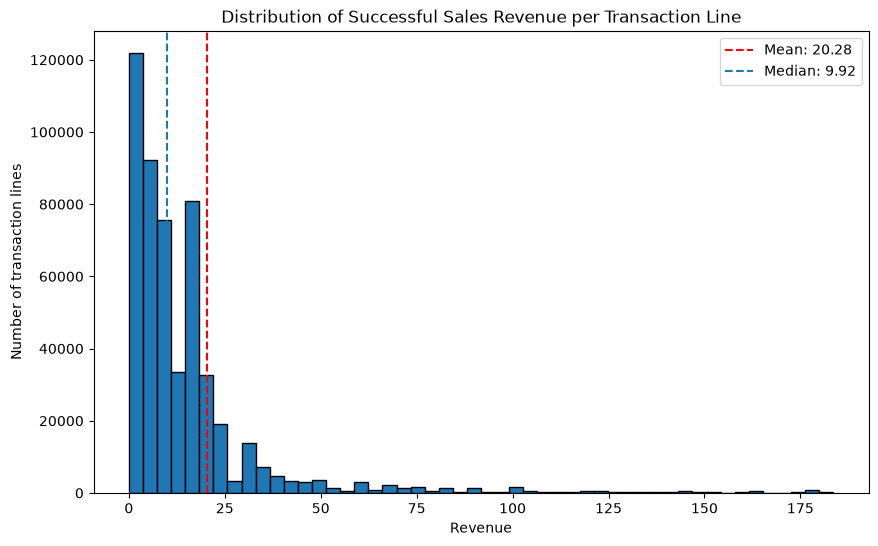

In [63]:
plt.figure(figsize=(10, 6))

plt.hist(
    revenue_for_plot["revenue"],
    bins=50,
    edgecolor="black"
)

plt.axvline(
    revenue.mean(),
    linestyle="--",
    label=f"Mean: {revenue.mean():.2f}",
    color="red"
)

plt.axvline(
    revenue.median(),
    linestyle="--",
    label=f"Median: {revenue.median():.2f}"
)

plt.title("Distribution of Successful Sales Revenue per Transaction Line")
plt.xlabel("Revenue")
plt.ylabel("Number of transaction lines")
plt.legend()
plt.show()

### Investigate extreme revenue values

In [64]:
revenue_skewness = sales_df["revenue"].skew()

revenue_skewness

np.float64(504.2325621167678)

In [65]:
largest_revenue_df = sales_df.nlargest(10, "revenue").copy()

In [66]:
columns_to_show = [
    "invoice_no",
    "stock_code",
    "description",
    "quantity",
    "unit_price",
    "revenue",
    "customer_id",
    "country",
    "invoice_date",
]

largest_revenue_df[columns_to_show]

,invoice_no,stock_code,description,quantity,unit_price,revenue,customer_id,country,invoice_date
532648,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446.0,United Kingdom,2011-12-09 09:15:00
60678,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346.0,United Kingdom,2011-01-18 10:01:00
219468,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,15098.0,United Kingdom,2011-06-10 15:28:00
14634,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33,NaN,United Kingdom,2010-12-07 15:08:00
295942,A563185,B,Adjust bad debt,1,11062.06,11062.06,NaN,United Kingdom,2011-08-12 14:50:00
170792,551697,POST,POSTAGE,1,8142.75,8142.75,16029.0,United Kingdom,2011-05-03 13:46:00
343740,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72,17450.0,United Kingdom,2011-09-20 11:05:00
51851,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom,2011-01-11 12:55:00
158142,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom,2011-04-18 13:20:00
415941,573003,23084,RABBIT NIGHT LIGHT,2400,2.08,4992.00,14646.0,Netherlands,2011-10-27 12:11:00


In [67]:
largest_revenue_df[
    ["quantity", "unit_price", "revenue"]
].describe()

,quantity,unit_price,revenue
count,10.000000,10.00000,10.000000
mean,16531.300000,3341.01000,34258.486000
std,32253.111464,5383.50963,52339.779075
min,1.000000,1.04000,4992.000000
25%,15.750000,2.08500,6690.730000
50%,1906.000000,3.58000,9602.405000
75%,3114.000000,6269.43750,32612.832500
max,80995.000000,13541.33000,168469.600000


In [68]:
largest_revenue_df["invoice_no"].value_counts()

invoice_no
581483     1
541431     1
556444     1
537632     1
A563185    1
551697     1
567423     1
540815     1
550461     1
573003     1
Name: count, dtype: int64

In [69]:
monthly_revenue_df = (
    sales_df
    .groupby("year_month", as_index=False)["revenue"]
    .sum()
    .rename(columns={"revenue": "monthly_revenue"})
    .sort_values("year_month")
)

monthly_revenue_df

,year_month,monthly_revenue
0,2010-12,821452.730
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,757841.380
9,2011-09,1056435.192


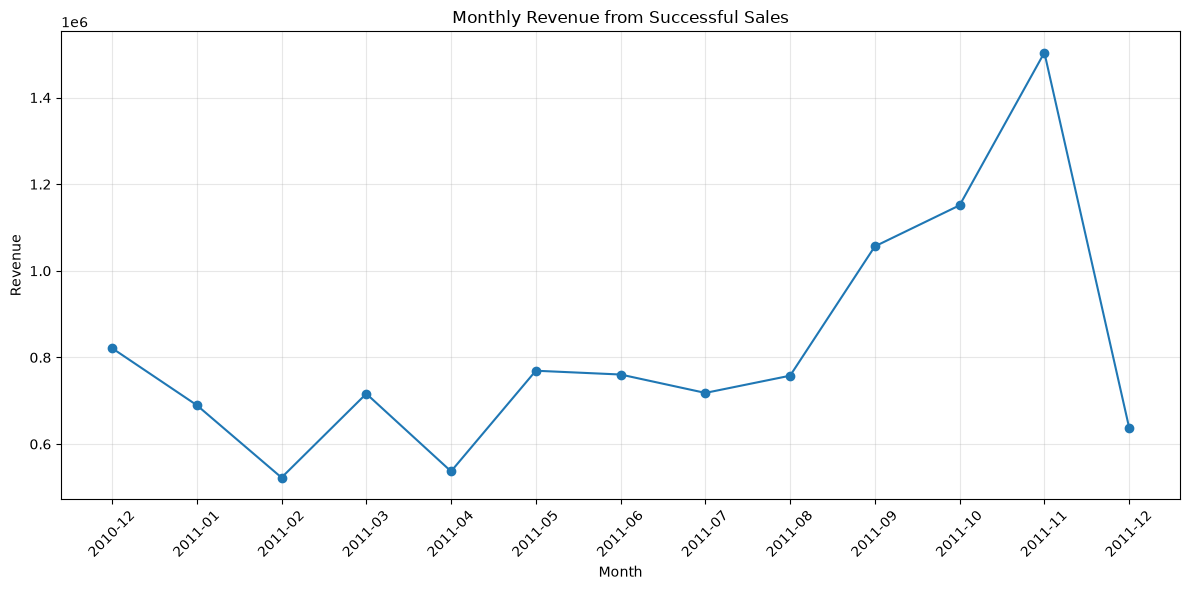

In [70]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue_df["year_month"],
    monthly_revenue_df["monthly_revenue"],
    marker="o",
)

plt.title("Monthly Revenue from Successful Sales")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [71]:
sales_df["invoice_date"].min(), sales_df["invoice_date"].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

In [72]:
customer_revenue_df = (
    sales_df
    .groupby("customer_id", as_index=False)["revenue"]
    .sum()
    .rename(columns={"revenue": "customer_revenue"})
    .sort_values("customer_revenue", ascending=False)
)

customer_revenue_df.head()

,customer_id,customer_revenue
1689,14646.0,280206.02
4201,18102.0,259657.30
3728,17450.0,194390.79
3008,16446.0,168472.50
1879,14911.0,143711.17


In [73]:
import math

total_customers = len(customer_revenue_df)

top_10_count = math.ceil(total_customers * 0.10)

total_customer_revenue = customer_revenue_df[
    "customer_revenue"
].sum()

top_10_revenue = customer_revenue_df.head(
    top_10_count
)["customer_revenue"].sum()

top_10_revenue_share = (
    top_10_revenue
    / total_customer_revenue
    * 100
)

print(f"Identified customers: {total_customers:,}")
print(f"Customers in top 10%: {top_10_count:,}")
print(f"Total identified-customer revenue: {total_customer_revenue:,.2f}")
print(f"Top 10% customer revenue: {top_10_revenue:,.2f}")
print(f"Top 10% revenue share: {top_10_revenue_share:.2f}%")

Identified customers: 4,338
Customers in top 10%: 434
Total identified-customer revenue: 8,887,208.89
Top 10% customer revenue: 5,461,374.89
Top 10% revenue share: 61.45%


### Customer concentration interpretation

**Observation:**  
The top 10% of identified customers generate approximately 61.45% of identified-customer revenue.

**Business meaning:**  
Revenue is highly concentrated among a relatively small group of customers. These customers may be especially important for retention, loyalty programs, personalized offers, or account management.

**Business risk:**  
The retailer may be vulnerable if a significant number of these high-value customers reduce or stop their purchases.

**Possible action:**  
The company could identify the characteristics of these customers, monitor their activity, and design targeted retention strategies.

**Limitation:**  
Customers without a customer ID are excluded. Revenue also does not represent profitability, acquisition cost, or future customer value.

In [79]:
operational_entries = [
    "DOTCOM POSTAGE",
    "POSTAGE",
    "AMAZON FEE",
    "Adjust bad debt",
]

product_sales_df = sales_df[
    ~sales_df["description"].isin(operational_entries)
].copy()

In [82]:
product_revenue_df = (
    product_sales_df
    .groupby("description", as_index=False)["revenue"]
    .sum()
    .rename(columns={"revenue": "product_revenue"})
    .sort_values("product_revenue", ascending=False)
)
product_revenue_df.head()

,description,product_revenue
2838,REGENCY CAKESTAND 3 TIER,174156.54
2375,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3829,WHITE HANGING HEART T-LIGHT HOLDER,106236.72
2400,PARTY BUNTING,99445.23
1802,JUMBO BAG RED RETROSPOT,94159.81


In [83]:
total_products = len(product_revenue_df)
total_product_revenue = product_revenue_df["product_revenue"].sum()
top_10_product_count = math.ceil(total_products * 0.10)
top_10_product_revenue = product_revenue_df.head(
    top_10_product_count
)["product_revenue"].sum()
top_10_product_revenue_share = (
    top_10_product_revenue
    / total_product_revenue
    * 100
)

print(f"Identified products: {total_products:,}")
print(f"Products in top 10%: {top_10_product_count:,}")
print(f"Total identified-product revenue: {total_product_revenue:,.2f}")
print(f"Top 10% product revenue: {top_10_product_revenue:,.2f}")
print(f"Top 10% revenue share: {top_10_product_revenue_share:.2f}%")

Identified products: 4,011
Products in top 10%: 402
Total identified-product revenue: 10,332,937.00
Top 10% product revenue: 6,407,795.42
Top 10% revenue share: 62.01%


In [84]:
top_products_df = product_revenue_df.head(10).sort_values(
    "product_revenue"
)

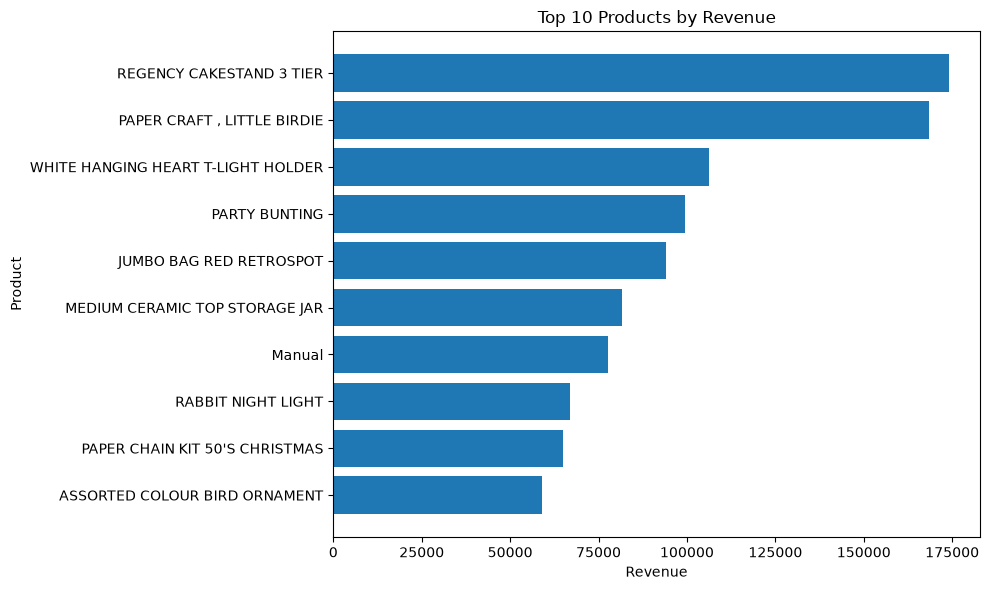

In [85]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_products_df["description"],
    top_products_df["product_revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### Top-product interpretation

**Observation:**  
`REGENCY CAKESTAND 3 TIER` generates the highest revenue among the non-operational product descriptions.

**Business meaning:**  
The retailer should closely monitor the stock availability, demand trend, and seasonal performance of the highest-revenue products.

**Risk:**  
If a large share of revenue depends on a small number of products, stock shortages or declining demand could significantly affect total sales.

**Limitation:**  
Revenue alone does not show profitability. A product may generate high revenue but also have high purchasing costs, return rates, or low margins.

In [86]:
customer_orders_df = (
    sales_df
    .dropna(subset=["customer_id"])
    .groupby("customer_id", as_index=False)["invoice_no"]
    .nunique()
    .rename(columns={"invoice_no": "number_of_orders"})
)

customer_orders_df.head()

,customer_id,number_of_orders
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


In [87]:
total_identified_customers = len(customer_orders_df)

one_time_customers = (
    customer_orders_df["number_of_orders"] == 1
).sum()

repeat_customers = (
    customer_orders_df["number_of_orders"] > 1
).sum()

repeat_customer_rate = (
    repeat_customers
    / total_identified_customers
    * 100
)

print(f"Total identified customers: {total_identified_customers:,}")
print(f"One-time customers: {one_time_customers:,}")
print(f"Repeat customers: {repeat_customers:,}")
print(f"Repeat customer rate: {repeat_customer_rate:.2f}%")

Total identified customers: 4,338
One-time customers: 1,493
Repeat customers: 2,845
Repeat customer rate: 65.58%


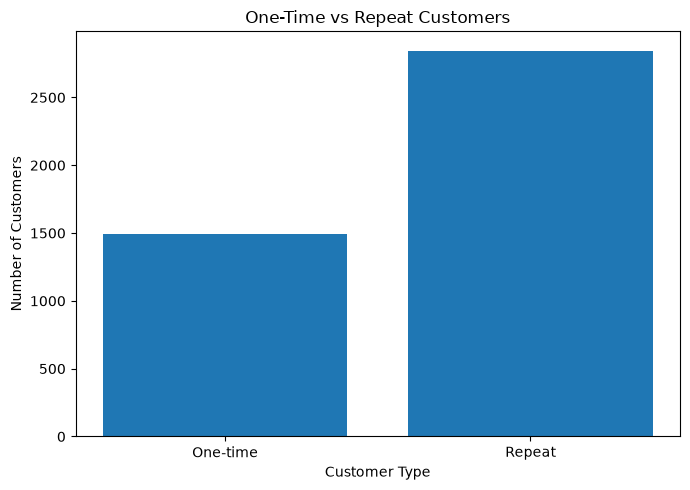

In [88]:
customer_type_df = pd.DataFrame({
    "customer_type": ["One-time", "Repeat"],
    "number_of_customers": [
        one_time_customers,
        repeat_customers
    ]
})

plt.figure(figsize=(7, 5))

plt.bar(
    customer_type_df["customer_type"],
    customer_type_df["number_of_customers"]
)

plt.title("One-Time vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()